In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
project_root = Path("/Users/lipikam/Desktop/MinorProject/ANSC4040MiniProject")
file_path = project_root / "Data_set_prep_assignment_1.csv"

# Keep AnimalId as text so large identifiers are not rounded by floating-point conversion.
df = pd.read_csv(file_path, low_memory=False, dtype={"AnimalId": "string"})
df = df.rename(columns={
    "Avgmilkflow": "AverageMilkFlowKgPerMin",
    "Flow30_60Session": "MilkFlow30To60SecondsKgPerMin",
    "YieldFirst2Min_Session": "MilkYieldFirst2MinutesKg",
    "YieldSession": "TotalMilkYieldSessionKg",
    "DurationSession_sec": "MilkingDurationSessionSeconds",
    "milking": "MilkingSession"
})
df["EventDate"] = pd.to_datetime(df["EventDate"], errors="coerce")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 8,495,421
Columns: 11


,AnimalId,LactationNumber,DaysInMilk,ReproductionStatus,EventDate,AverageMilkFlowKgPerMin,MilkFlow30To60SecondsKgPerMin,MilkYieldFirst2MinutesKg,TotalMilkYieldSessionKg,MilkingDurationSessionSeconds,MilkingSession
0,-8839528597343470980,1.0,365.0,Pregnant,2019-12-09,2.902991,0.898113,4.975908,11.158372,226,1
1,-5365332022005618386,1.0,66.0,Bred,2021-07-12,3.311224,1.401600,5.347854,15.059267,268,2
2,<NA>,NaN,NaN,NaN,2020-08-24,3.220506,3.501733,7.547777,14.560315,270,1
3,7750423760892252046,1.0,244.0,Pregnant,2019-12-04,3.900894,4.100475,8.400531,15.331422,231,3
4,<NA>,NaN,NaN,NaN,2021-03-21,4.218409,5.098378,9.198853,13.970645,198,2


In [7]:
#understand the missingess of the data
data_quality = pd.DataFrame({
    "DataType": df.dtypes.astype(str),
    "MissingCount": df.isna().sum(),
    "MissingPercent": (df.isna().mean() * 100).round(2),
    "UniqueValues": df.nunique(dropna=True)
}).sort_values("MissingPercent", ascending=False)
display(data_quality)

,DataType,MissingCount,MissingPercent,UniqueValues
AnimalId,string,1701003,20.02,9087
LactationNumber,float64,1701003,20.02,12
DaysInMilk,float64,1701007,20.02,870
ReproductionStatus,str,1701003,20.02,4
EventDate,datetime64[us],0,0.00,830
AverageMilkFlowKgPerMin,float64,172,0.00,219
MilkFlow30To60SecondsKgPerMin,float64,0,0.00,102
MilkYieldFirst2MinutesKg,float64,0,0.00,1675
TotalMilkYieldSessionKg,float64,0,0.00,1010
MilkingDurationSessionSeconds,int64,0,0.00,604


In [11]:
numeric_columns = df.select_dtypes(include="number").columns

dataset_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Total columns",
        "Minimum event date",
        "Maximum event date",
        "Number of unique AnimalId values"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["EventDate"].min(),
        df["EventDate"].max(),
        df["AnimalId"].nunique(dropna=True)
    ]
})
display(dataset_summary)

,Metric,Value
0,Total records,8495421
1,Total columns,11
2,Minimum event date,2019-06-14 00:00:00
3,Maximum event date,2021-10-24 00:00:00
4,Number of unique AnimalId values,9087


In [12]:
numeric_summary = df[numeric_columns].describe().T
numeric_summary["Range"] = numeric_summary["max"] - numeric_summary["min"]
numeric_summary["MissingCount"] = df[numeric_columns].isna().sum()
numeric_summary["MissingPercent"] = (df[numeric_columns].isna().mean() * 100).round(2)

display(numeric_summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "Range", "MissingCount", "MissingPercent"]
])

,count,mean,std,min,25%,50%,75%,max,Range,MissingCount,MissingPercent
LactationNumber,6794418.0,2.293987,1.387657,1.000000,1.000000,2.000000,3.000000,12.000000,11.000000,1701003,20.02
DaysInMilk,6794414.0,162.929680,105.518817,1.000000,76.000000,154.000000,237.000000,870.000000,869.000000,1701007,20.02
AverageMilkFlowKgPerMin,8495249.0,3.525963,0.729143,0.000000,2.993710,3.492661,3.991613,23.496085,23.496085,172,0.00
MilkFlow30To60SecondsKgPerMin,8495421.0,3.751556,1.485679,0.000000,2.798665,3.900894,4.898798,10.500663,10.500663,0,0.00
MilkYieldFirst2MinutesKg,8495421.0,7.491106,2.014112,2.000342,6.023707,7.525097,8.999273,11.997518,9.997176,0,0.00
TotalMilkYieldSessionKg,8495421.0,13.928465,3.645984,5.034875,11.430528,13.743849,16.329325,54.839318,49.804442,0,0.00
MilkingDurationSessionSeconds,8495421.0,236.863760,54.843281,100.000000,197.000000,231.000000,272.000000,785.000000,685.000000,0,0.00
MilkingSession,8495421.0,2.000000,0.816497,1.000000,1.000000,2.000000,3.000000,3.000000,2.000000,0,0.00


In [8]:
missing_columns = ["AnimalId", "LactationNumber", "DaysInMilk", "ReproductionStatus"]
missing_pattern = (
    df[missing_columns].isna()
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
    .value_counts()
    .rename_axis("MissingPattern")
    .reset_index(name="RecordCount")
)
missing_pattern["Percent"] = (missing_pattern["RecordCount"] / len(df) * 100).round(2)
display(missing_pattern)

missing_id_summary = pd.DataFrame({
    "RecordsWithAnimalId": [df["AnimalId"].notna().sum()],
    "RecordsMissingAnimalId": [df["AnimalId"].isna().sum()],
    "MissingAnimalIdPercent": [round(df["AnimalId"].isna().mean() * 100, 2)]
})
display(missing_id_summary)

,MissingPattern,RecordCount,Percent
0,0000,6794414,79.98
1,1111,1701003,20.02
2,0010,4,0.00


,RecordsWithAnimalId,RecordsMissingAnimalId,MissingAnimalIdPercent
0,6794418,1701003,20.02


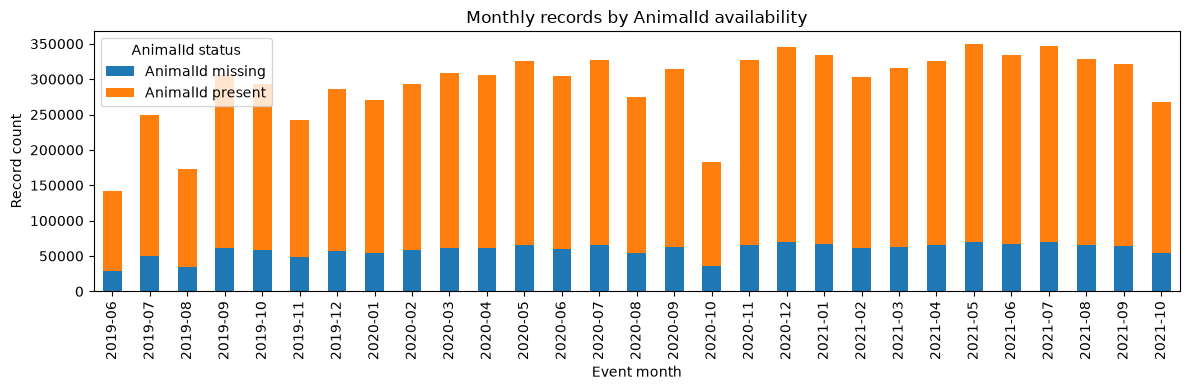

In [20]:
monthly_animal_id_status = pd.crosstab(
    df["EventDate"].dt.to_period("M"),
    df["AnimalId"].isna().map({False: "AnimalId present", True: "AnimalId missing"})
)

monthly_animal_id_status.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4)
)
plt.title("Monthly records by AnimalId availability")
plt.xlabel("Event month")
plt.ylabel("Record count")
plt.legend(title="AnimalId status")
plt.tight_layout()
plt.show()

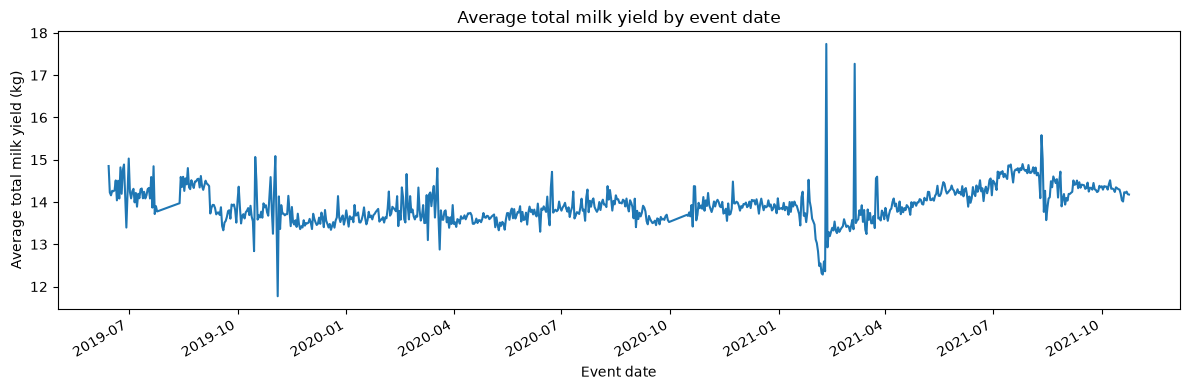

In [9]:
#Daily milk yield analysis
daily_milk_yield = df.groupby("EventDate")["TotalMilkYieldSessionKg"].mean()

daily_milk_yield.plot(figsize=(12, 4))
plt.title("Average total milk yield by event date")
plt.xlabel("Event date")
plt.ylabel("Average total milk yield (kg)")
plt.tight_layout()
plt.show()

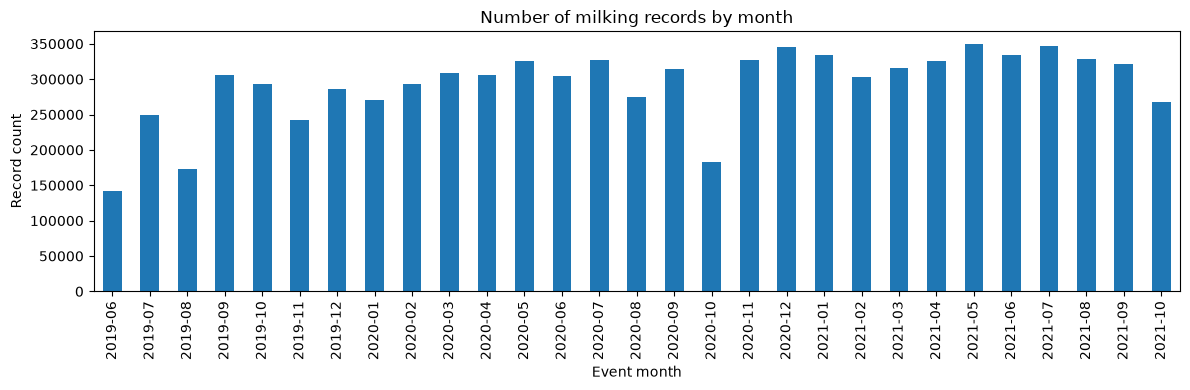

In [10]:
monthly_record_counts = df.groupby(df["EventDate"].dt.to_period("M")).size()

monthly_record_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Number of milking records by month")
plt.xlabel("Event month")
plt.ylabel("Record count")
plt.tight_layout()
plt.show()

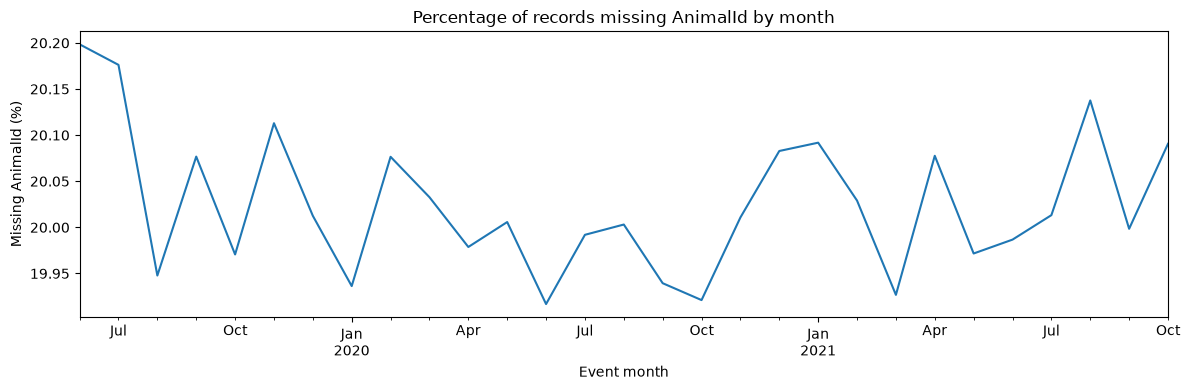

In [13]:
monthly_missing_id_rate = df.groupby(df["EventDate"].dt.to_period("M"))["AnimalId"].apply(
    lambda values: values.isna().mean() * 100
)

monthly_missing_id_rate.plot(figsize=(12, 4))
plt.title("Percentage of records missing AnimalId by month")
plt.xlabel("Event month")
plt.ylabel("Missing AnimalId (%)")
plt.tight_layout()
plt.show()

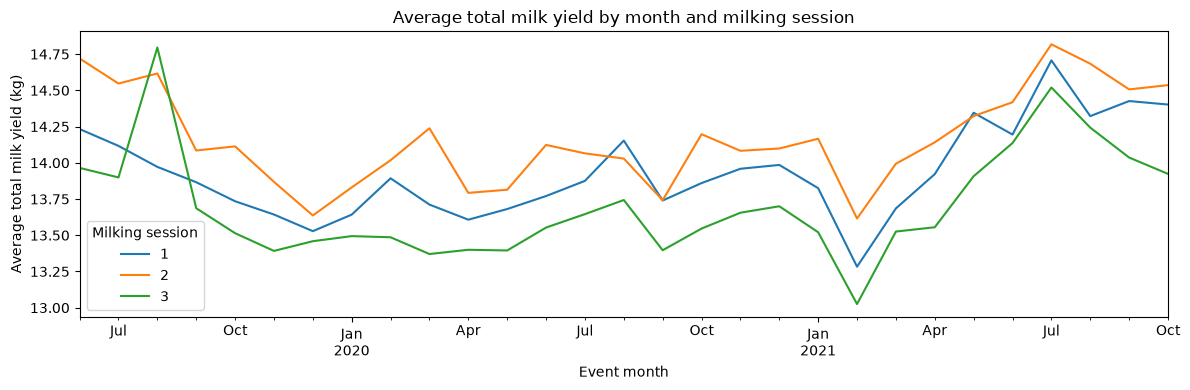

In [14]:
monthly_session_yield = (
    df.groupby([df["EventDate"].dt.to_period("M"), "MilkingSession"])
    ["TotalMilkYieldSessionKg"]
    .mean()
    .unstack()
)

monthly_session_yield.plot(figsize=(12, 4))
plt.title("Average total milk yield by month and milking session")
plt.xlabel("Event month")
plt.ylabel("Average total milk yield (kg)")
plt.legend(title="Milking session")
plt.tight_layout()
plt.show()

In [15]:
#Duplication analysis
full_duplicate_count = int(df.duplicated(keep=False).sum())
full_duplicate_groups = int(df.duplicated(keep=False).groupby(df.duplicated(keep=False)).sum().get(True, 0))
print(f"Rows belonging to full-row duplicate groups: {full_duplicate_count:,}")
print(f"Number of duplicate rows beyond the first copy: {full_duplicate_groups:,}")

Rows belonging to full-row duplicate groups: 111,487
Number of duplicate rows beyond the first copy: 111,487


In [17]:
#Create fingerprint of the data to identify unique records based on key columns
fingerprint_columns = [
    "EventDate",
    "AverageMilkFlowKgPerMin",
    "MilkFlow30To60SecondsKgPerMin",
    "MilkYieldFirst2MinutesKg",
    "TotalMilkYieldSessionKg",
    "MilkingDurationSessionSeconds",
    "MilkingSession"
]

known_id_rows = df[df["AnimalId"].notna()].copy()
missing_id_rows = df[df["AnimalId"].isna()].copy()

fingerprint_counts = (
    df.groupby(fingerprint_columns, dropna=False, sort=False)
    .agg(
        RecordCount=("AnimalId", "size"),
        KnownIdCount=("AnimalId", "nunique"),
        KnownIds=("AnimalId", lambda values: ", ".join(sorted(values.dropna().unique())))
    )
    .reset_index()
)
fingerprint_counts["HasMissingId"] = fingerprint_counts["KnownIdCount"] < fingerprint_counts["RecordCount"]
fingerprint_counts["IsUniqueKnownId"] = (
    fingerprint_counts["HasMissingId"] & (fingerprint_counts["KnownIdCount"] == 1)
)
display(fingerprint_counts["IsUniqueKnownId"].value_counts(dropna=False).rename("FingerprintGroups"))
display(fingerprint_counts.sort_values(["IsUniqueKnownId", "RecordCount"], ascending=False).head(20))

IsUniqueKnownId
False    8343386
True       66716
Name: FingerprintGroups, dtype: int64

,EventDate,AverageMilkFlowKgPerMin,MilkFlow30To60SecondsKgPerMin,MilkYieldFirst2MinutesKg,TotalMilkYieldSessionKg,MilkingDurationSessionSeconds,MilkingSession,RecordCount,KnownIdCount,KnownIds,HasMissingId,IsUniqueKnownId
305657,2019-12-18,3.492661,3.900894,7.175831,13.743849,235,1,5,1,2309704041517516606,True,True
208,2019-12-18,2.721554,2.599084,5.098378,11.611965,256,2,4,1,5438335567076688939,True,True
304,2019-12-19,2.222603,2.000342,4.749112,11.022295,289,2,4,1,-8755940647243117386,True,True
648,2019-12-19,3.583380,4.499636,8.096624,9.979032,166,2,4,1,-5942447048067441123,True,True
803,2019-12-19,2.902991,1.102229,6.250503,9.026488,181,1,4,1,8781517156755921935,True,True
1181,2019-12-19,3.311224,3.302152,6.540802,13.834567,248,1,4,1,1984305533479884444,True,True
1344,2019-12-19,2.585477,2.499294,4.826223,13.834567,318,1,4,1,-4660542817531708009,True,True
1456,2019-12-19,3.311224,0.997903,6.023707,13.380975,243,1,4,1,8033604509564778936,True,True
1547,2019-12-19,3.401943,3.801104,7.148616,16.283966,285,2,4,1,-5305210815022621746,True,True
1661,2019-12-19,2.902991,3.098036,6.023707,10.704780,217,1,4,1,-3095996829835093995,True,True


In [19]:
# Checking if we can match duplicate rows with missing AnimalId to a unique known AnimalId 
# based on the fingerprint columns
unique_known_fingerprints = fingerprint_counts.loc[
    fingerprint_counts["IsUniqueKnownId"],
    fingerprint_columns + ["KnownIds"]
].rename(columns={"KnownIds": "CandidateAnimalId"})

exact_match_candidates = missing_id_rows.merge(
    unique_known_fingerprints,
    on=fingerprint_columns,
    how="inner"
)

print(f"Missing-ID rows with a unique exact fingerprint match: {len(exact_match_candidates):,}")
display(exact_match_candidates[["CandidateAnimalId"] + fingerprint_columns].head(20))

Missing-ID rows with a unique exact fingerprint match: 25,941


,CandidateAnimalId,EventDate,AverageMilkFlowKgPerMin,MilkFlow30To60SecondsKgPerMin,MilkYieldFirst2MinutesKg,TotalMilkYieldSessionKg,MilkingDurationSessionSeconds,MilkingSession
0,726309735535000823,2020-05-27,3.220506,4.499636,6.577089,6.849245,128,2
1,1111771149845686185,2021-06-08,2.494758,2.998246,5.474860,10.115110,237,2
2,-1137436016399384289,2021-06-08,2.902991,2.499294,5.325174,15.648937,316,2
3,-5677228125449135544,2021-10-07,2.404040,3.401943,5.288887,5.987419,145,1
4,6053388255801157224,2021-07-06,2.812273,0.798323,4.599427,13.562412,288,1
5,-2686849451413274386,2021-10-07,2.993710,3.401943,6.050922,13.199538,258,2
6,6282032239950184441,2019-12-19,2.902991,3.501733,6.223287,11.657324,234,1
7,-7249502135335264644,2021-10-07,4.717361,6.100817,10.899825,16.465403,208,2
8,-4598842436109611749,2021-10-06,2.494758,3.197826,5.751551,8.255381,192,1
9,2783075508045834275,2021-07-06,4.218409,4.898798,9.348539,18.688006,263,3


In [ ]:
#checking the missingness of the AnimalId by date, if any pattern exists
missing_id_by_date = (
    df.groupby("EventDate")
    .agg(
        TotalRecords=("AnimalId", "size"),
        KnownIdRecords=("AnimalId", lambda values: values.notna().sum()),
        MissingIdRecords=("AnimalId", lambda values: values.isna().sum())
    )
    .assign(
        MissingIdPercent=lambda table: (
            table["MissingIdRecords"] / table["TotalRecords"] * 100
        ).round(2)
    )
    .reset_index()
)

display(missing_id_by_date)

,EventDate,TotalRecords,KnownIdRecords,MissingIdRecords,MissingIdPercent
0,2019-06-14,2850,2256,594,20.84
1,2019-06-15,9972,8025,1947,19.52
2,2019-06-16,10710,8551,2159,20.16
3,2019-06-17,10473,8347,2126,20.30
4,2019-06-18,10245,8152,2093,20.43
...,...,...,...,...,...
825,2021-10-20,11166,8907,2259,20.23
826,2021-10-21,10923,8684,2239,20.50
827,2021-10-22,10833,8698,2135,19.71
828,2021-10-23,11214,8983,2231,19.89


In [ ]:
#checking the missingness of the AnimalId by milking session, if any pattern exists
missing_id_by_session = (
    df.groupby("MilkingSession", dropna=False)
    .agg(
        TotalRecords=("AnimalId", "size"),
        KnownIdRecords=("AnimalId", lambda values: values.notna().sum()),
        MissingIdRecords=("AnimalId", lambda values: values.isna().sum())
    )
    .assign(
        MissingIdPercent=lambda table: (
            table["MissingIdRecords"] / table["TotalRecords"] * 100
        ).round(2)
    )
    .reset_index()
)

display(missing_id_by_session)

,MilkingSession,TotalRecords,KnownIdRecords,MissingIdRecords,MissingIdPercent
0,1,2831807,2264653,567154,20.03
1,2,2831807,2264429,567378,20.04
2,3,2831807,2265336,566471,20.00


In [25]:
missing_id_by_date_session = (
    df.groupby(["EventDate", "MilkingSession"], dropna=False)
    .agg(
        TotalRecords=("AnimalId", "size"),
        KnownIdRecords=("AnimalId", lambda values: values.notna().sum()),
        MissingIdRecords=("AnimalId", lambda values: values.isna().sum())
    )
    .assign(
        MissingIdPercent=lambda table: (
            table["MissingIdRecords"] / table["TotalRecords"] * 100
        ).round(2)
    )
    .reset_index()
)

display(missing_id_by_date_session)

,EventDate,MilkingSession,TotalRecords,KnownIdRecords,MissingIdRecords,MissingIdPercent
0,2019-06-14,1,950,754,196,20.63
1,2019-06-14,2,950,750,200,21.05
2,2019-06-14,3,950,752,198,20.84
3,2019-06-15,1,3324,2700,624,18.77
4,2019-06-15,2,3324,2638,686,20.64
...,...,...,...,...,...,...
2485,2021-10-23,2,3738,2994,744,19.90
2486,2021-10-23,3,3738,3010,728,19.48
2487,2021-10-24,1,2590,2022,568,21.93
2488,2021-10-24,2,2590,2074,516,19.92


In [26]:
# Identify consecutive date intervals containing missing AnimalId records
date_missing_status = (
    missing_id_by_date[["EventDate", "MissingIdRecords"]]
    .sort_values("EventDate")
    .copy()
)
date_missing_status["HasMissingIds"] = date_missing_status["MissingIdRecords"] > 0
date_missing_status["NewInterval"] = (
    date_missing_status["EventDate"].diff().dt.days.ne(1)
    | date_missing_status["HasMissingIds"].ne(
        date_missing_status["HasMissingIds"].shift()
    )
)
date_missing_status["IntervalId"] = date_missing_status["NewInterval"].cumsum()

missing_id_intervals = (
    date_missing_status[date_missing_status["HasMissingIds"]]
    .groupby("IntervalId")
    .agg(
        IntervalStart=("EventDate", "min"),
        IntervalEnd=("EventDate", "max"),
        DatesWithMissingIds=("EventDate", "nunique"),
        MissingIdRecords=("MissingIdRecords", "sum")
    )
    .assign(
        CalendarDays=lambda table: (
            table["IntervalEnd"] - table["IntervalStart"]
        ).dt.days + 1
    )
    .reset_index(drop=True)
)

missing_id_interval_summary = pd.DataFrame({
    "FirstDateWithMissingIds": [date_missing_status.loc[date_missing_status["HasMissingIds"], "EventDate"].min()],
    "LastDateWithMissingIds": [date_missing_status.loc[date_missing_status["HasMissingIds"], "EventDate"].max()],
    "DatesWithMissingIds": [date_missing_status["HasMissingIds"].sum()],
    "TotalDates": [len(date_missing_status)]
})

display(missing_id_interval_summary)
display(missing_id_intervals)

,FirstDateWithMissingIds,LastDateWithMissingIds,DatesWithMissingIds,TotalDates
0,2019-06-14,2021-10-24,830,830


,IntervalStart,IntervalEnd,DatesWithMissingIds,MissingIdRecords,CalendarDays
0,2019-06-14,2019-06-27,14,25474,14
1,2019-06-29,2019-07-25,27,53451,27
2,2019-08-13,2019-10-27,76,150197,76
3,2019-10-29,2020-09-30,338,654479,338
4,2020-10-15,2021-10-24,375,817402,375


In [27]:
# Examine gaps between dates on which each known animal was observed
known_animal_dates = (
    df[df["AnimalId"].notna()][["AnimalId", "EventDate"]]
    .drop_duplicates()
    .sort_values(["AnimalId", "EventDate"])
    .copy()
)
known_animal_dates["GapDays"] = (
    known_animal_dates.groupby("AnimalId")["EventDate"].diff().dt.days
)

known_animal_gap_summary = (
    known_animal_dates.groupby("AnimalId")
    .agg(
        FirstObservedDate=("EventDate", "min"),
        LastObservedDate=("EventDate", "max"),
        DatesObserved=("EventDate", "nunique"),
        LargestGapDays=("GapDays", "max"),
        NumberOfGaps=("GapDays", lambda values: values.gt(1).sum())
    )
    .reset_index()
)

known_animal_gap_overview = pd.DataFrame({
    "KnownAnimals": [known_animal_gap_summary["AnimalId"].nunique()],
    "AnimalsWithDateGaps": [(known_animal_gap_summary["NumberOfGaps"] > 0).sum()],
    "LargestObservedGapDays": [known_animal_gap_summary["LargestGapDays"].max()]
})

display(known_animal_gap_overview)
display(known_animal_gap_summary.sort_values("LargestGapDays", ascending=False).head(20))

,KnownAnimals,AnimalsWithDateGaps,LargestObservedGapDays
0,9087,8963,436.0


,AnimalId,FirstObservedDate,LastObservedDate,DatesObserved,LargestGapDays,NumberOfGaps
5895,3413217461804626118,2019-06-16,2021-10-24,287,436.0,44
3824,-7973184776899764901,2019-06-15,2021-10-24,367,433.0,20
2031,-473862980338908920,2019-06-15,2020-12-30,69,431.0,8
3260,-6992903936765137106,2020-03-27,2021-05-27,5,422.0,2
7867,7058986763739640659,2019-06-15,2021-10-24,348,420.0,20
5122,2072412466951886429,2019-06-16,2021-05-31,236,413.0,43
2425,-5453650804544493161,2019-06-15,2021-09-10,195,402.0,66
4946,1747164882779520695,2019-06-14,2021-09-05,291,383.0,62
7902,71092527785309738,2019-06-15,2021-08-30,308,344.0,78
2210,-5058402842964348140,2019-06-16,2021-09-28,126,311.0,44


In [28]:
# Identify known animals that disappear from the known-ID data and later reappear
animal_reappearance_gaps = (
    known_animal_dates[known_animal_dates["GapDays"] > 1]
    .assign(
        GapStart=lambda table: table["EventDate"] - pd.to_timedelta(table["GapDays"], unit="D"),
        GapEnd=lambda table: table["EventDate"]
    )
    [["AnimalId", "GapStart", "GapEnd", "GapDays"]]
    .sort_values("GapDays", ascending=False)
    .reset_index(drop=True)
)

animal_reappearance_summary = pd.DataFrame({
    "AnimalsWithReappearanceGaps": [animal_reappearance_gaps["AnimalId"].nunique()],
    "ReappearanceGapIntervals": [len(animal_reappearance_gaps)],
    "LongestReappearanceGapDays": [animal_reappearance_gaps["GapDays"].max()]
})

display(animal_reappearance_summary)
display(animal_reappearance_gaps.head(20))

,AnimalsWithReappearanceGaps,ReappearanceGapIntervals,LongestReappearanceGapDays
0,8963,420665,436.0


,AnimalId,GapStart,GapEnd,GapDays
0,3413217461804626118,2019-07-14,2020-09-22,436.0
1,-7973184776899764901,2019-07-25,2020-09-30,433.0
2,-473862980338908920,2019-06-30,2020-09-03,431.0
3,-6992903936765137106,2020-03-30,2021-05-26,422.0
4,7058986763739640659,2019-07-09,2020-09-01,420.0
5,2072412466951886429,2019-07-25,2020-09-10,413.0
6,-5453650804544493161,2019-06-30,2020-08-05,402.0
7,1747164882779520695,2019-08-19,2020-09-05,383.0
8,71092527785309738,2019-09-24,2020-09-02,344.0
9,-5058402842964348140,2020-07-21,2021-05-28,311.0


In [29]:
# Summarise the observed history available for each known animal
known_animal_history = (
    known_id_rows.groupby("AnimalId")
    .agg(
        RecordCount=("AnimalId", "size"),
        FirstObservedDate=("EventDate", "min"),
        LastObservedDate=("EventDate", "max"),
        ObservedLactations=("LactationNumber", "nunique"),
        SessionsObserved=("MilkingSession", "nunique"),
        AverageMilkYieldKg=("TotalMilkYieldSessionKg", "mean"),
        MilkYieldStdKg=("TotalMilkYieldSessionKg", "std"),
        AverageMilkFlowKgPerMin=("AverageMilkFlowKgPerMin", "mean"),
        MilkFlowStdKgPerMin=("AverageMilkFlowKgPerMin", "std"),
        AverageMilkingDurationSeconds=("MilkingDurationSessionSeconds", "mean"),
        MilkingDurationStdSeconds=("MilkingDurationSessionSeconds", "std")
    )
    .reset_index()
    .merge(
        known_animal_gap_summary[["AnimalId", "LargestGapDays", "NumberOfGaps"]],
        on="AnimalId",
        how="left"
    )
)

display(known_animal_history.head(20))
display(known_animal_history.describe(include="all").T)

,AnimalId,RecordCount,FirstObservedDate,LastObservedDate,ObservedLactations,SessionsObserved,AverageMilkYieldKg,MilkYieldStdKg,AverageMilkFlowKgPerMin,MilkFlowStdKgPerMin,AverageMilkingDurationSeconds,MilkingDurationStdSeconds,LargestGapDays,NumberOfGaps
0,-1007048835775197250,1228,2019-06-15,2021-10-21,3,3,14.918867,2.905686,4.581948,0.523673,192.315147,27.958769,120.0,81
1,-1007468268464577766,1252,2019-06-15,2021-10-24,3,3,13.896194,3.641284,3.991758,0.774486,204.583866,29.790263,182.0,50
2,-1012797892009801154,394,2021-04-21,2021-10-24,1,3,11.620369,1.278648,4.330656,0.553402,161.868020,27.946292,3.0,21
3,-101666700114195127,787,2020-10-16,2021-09-21,1,3,14.255480,1.449092,3.489088,0.437564,244.952986,31.513503,3.0,19
4,-1016719360022315466,4,2021-10-23,2021-10-24,1,3,8.629595,1.030613,1.973127,0.086856,259.500000,39.745021,1.0,0
5,-1022783257967945650,99,2019-06-15,2019-08-20,1,3,13.581655,2.341045,3.383158,0.373200,236.858586,30.751808,21.0,3
6,-1023235798624875908,1,2019-10-02,2019-10-02,1,1,7.076041,NaN,2.404040,NaN,176.000000,NaN,NaN,0
7,-1024379415194528358,1141,2019-06-15,2021-08-10,3,3,12.473750,3.847917,3.216332,0.508935,224.639790,41.717165,162.0,66
8,-1025663298727082925,125,2020-07-16,2020-09-29,1,3,9.318602,1.456373,3.167889,0.389914,174.280000,21.000998,4.0,17
9,-1026049127512136481,19,2020-03-09,2020-03-25,1,3,5.858504,0.644013,2.318096,0.117987,149.210526,17.293476,5.0,3


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
AnimalId,9087,9087,-1007048835775197250,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RecordCount,9087.0,NaN,NaN,NaN,747.707494,1.0,313.0,704.0,1186.0,1763.0,492.065506
FirstObservedDate,9087,NaN,NaN,NaN,2020-01-14 06:52:58.078573,2019-06-14 00:00:00,2019-06-15 00:00:00,2019-07-25 00:00:00,2020-07-30 00:00:00,2021-10-24 00:00:00,NaN
LastObservedDate,9087,NaN,NaN,NaN,2021-04-02 00:12:02.614724,2019-06-15 00:00:00,2020-09-11 00:00:00,2021-09-27 00:00:00,2021-10-24 00:00:00,2021-10-24 00:00:00,NaN
ObservedLactations,9087.0,NaN,NaN,NaN,1.88357,1.0,1.0,2.0,3.0,4.0,0.831819
SessionsObserved,9087.0,NaN,NaN,NaN,2.996368,1.0,3.0,3.0,3.0,3.0,0.068698
AverageMilkYieldKg,9087.0,NaN,NaN,NaN,13.20689,5.170953,11.73598,13.387371,14.85394,23.525568,2.465429
MilkYieldStdKg,9082.0,NaN,NaN,NaN,2.603006,0.078565,1.836753,2.559386,3.297025,7.66458,0.959639
AverageMilkFlowKgPerMin,9087.0,NaN,NaN,NaN,3.427488,1.159181,3.019319,3.471664,3.869584,5.156373,0.608663
MilkFlowStdKgPerMin,9082.0,NaN,NaN,NaN,0.466509,0.0,0.349536,0.444854,0.565449,1.482815,0.164064


In [30]:
# Compare key measurements for records with known and missing AnimalId values
measurement_columns = [
    "AverageMilkFlowKgPerMin",
    "MilkFlow30To60SecondsKgPerMin",
    "MilkYieldFirst2MinutesKg",
    "TotalMilkYieldSessionKg",
    "MilkingDurationSessionSeconds"
]

measurement_distributions_by_id_status = (
    df.assign(IdStatus=df["AnimalId"].notna().map({True: "KnownId", False: "MissingId"}))
    .groupby("IdStatus")[measurement_columns]
    .agg(["count", "mean", "std", "median", "min", "max"])
)

display(measurement_distributions_by_id_status.T)

IdStatus                                   KnownId     MissingId
AverageMilkFlowKgPerMin       count   6.794287e+06  1.700962e+06
                              mean    3.525899e+00  3.526221e+00
                              std     7.291464e-01  7.291281e-01
                              median  3.492661e+00  3.492661e+00
                              min     0.000000e+00  0.000000e+00
                              max     2.349608e+01  2.349608e+01
MilkFlow30To60SecondsKgPerMin count   6.794418e+06  1.701003e+06
                              mean    3.751396e+00  3.752198e+00
                              std     1.485795e+00  1.485216e+00
                              median  3.900894e+00  3.900894e+00
                              min     0.000000e+00  0.000000e+00
                              max     1.050066e+01  1.010150e+01
MilkYieldFirst2MinutesKg      count   6.794418e+06  1.701003e+06
                              mean    7.490827e+00  7.492219e+00
                              std     2.014306e+00  2.013337e+00
                              median  7.525097e+00  7.525097e+00
                              min     2.000342e+00  2.000342e+00
                              max     1.199752e+01  1.199752e+01
TotalMilkYieldSessionKg       count   6.794418e+06  1.701003e+06
                              mean    1.392859e+01  1.392796e+01
                              std     3.645881e+00  3.646393e+00
                              median  1.374385e+01  1.374385e+01
                              min     5.034875e+00  5.034875e+00
                              max     5.483932e+01  5.397749e+01
MilkingDurationSessionSeconds count   6.794418e+06  1.701003e+06
                              mean    2.368709e+02  2.368352e+02
                              std     5.484436e+01  5.483898e+01
                              median  2.310000e+02  2.310000e+02
                              min     1.000000e+02  1.000000e+02
                              max     7.850000e+02  7.730000e+02

In [31]:
# Classify duplicate and fingerprint groups before deciding whether records should be removed
full_duplicate_summary = pd.DataFrame({
    "TotalFullDuplicateRowsBeyondFirst": [df.duplicated(keep="first").sum()],
    "FullDuplicateGroups": [df.value_counts().gt(1).sum()],
    "MissingIdRowsInFullDuplicates": [df[df["AnimalId"].isna()].duplicated(keep=False).sum()]
})

fingerprint_classification_summary = (
    fingerprint_counts.assign(
        FingerprintClass=lambda table: table["KnownIdCount"].map(
            lambda count: "NoKnownId" if count == 0
            else "OneKnownId" if count == 1
            else "MultipleKnownIds"
        )
    )
    .groupby("FingerprintClass")
    .agg(
        FingerprintGroups=("FingerprintClass", "size"),
        TotalRecords=("RecordCount", "sum"),
        GroupsWithMissingIds=("HasMissingId", "sum")
    )
    .reset_index()
)

display(full_duplicate_summary)
display(fingerprint_classification_summary)

,TotalFullDuplicateRowsBeyondFirst,FullDuplicateGroups,MissingIdRowsInFullDuplicates
0,60653,46929,8038


,FingerprintClass,FingerprintGroups,TotalRecords,GroupsWithMissingIds
0,MultipleKnownIds,300,612,5
1,NoKnownId,1672540,1675058,1672540
2,OneKnownId,6737262,6819751,66716
